# General-Purpose Visual Region Extraction and Geometry Evidence

Objective: extract **inspectable regions, color, shape, and relative geometry evidence** from images. Final species inference is intentionally reserved for a knowledge graph rather than a visual model.

An artificial flower with clear flower morphology is treated as a positive morphology case. Material authenticity is outside the task scope.

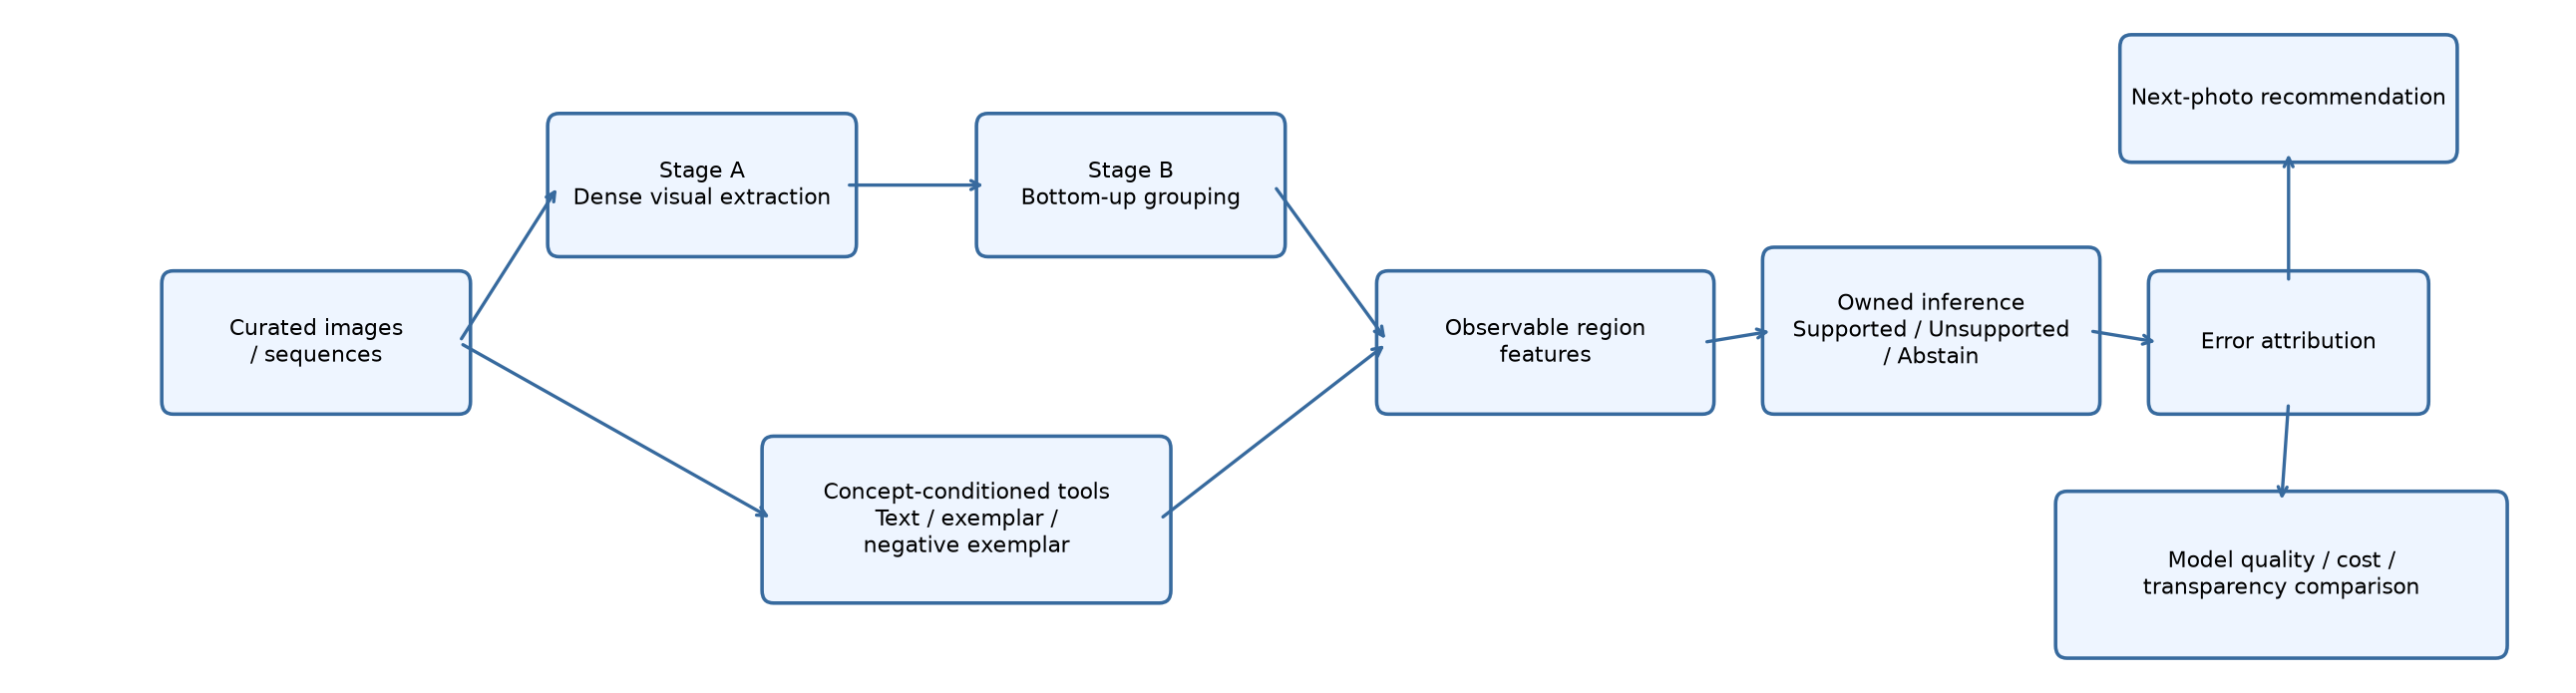

This is the target architecture. The current notebook executes Route A, the SAM baseline, and depth geometry. Concept-conditioned inference remains an interface owned by the knowledge graph rather than being replaced by CLIP.

## Notebook Structure

| Block | Purpose | Main output |
|---|---|---|
| **0. Shared input** | Curated images and human-checked coarse boxes | Box overview |
| **1. Route A** | Stage A extracts dense DINOv3 features; Stage B groups them bottom-up with K-means | PCA feature maps, groups, boundaries |
| **2. Route B** | Sends each coarse box directly to SAM | Cyan masks |
| **3. Supporting geometry** | Uses Depth Anything 3 for relative depth and three-view camera motion | Depth maps and camera centers |
| **4. Observable evidence** | Collects visual evidence that can be sent to a knowledge graph | Human-checkable evidence table |
| **5. Knowledge graph boundary** | Defines the boundary between vision output and final inference | KG input/output contract |
| **6–9. Diagnosis and summary** | Error attribution, recapture guidance, model comparison, conclusions | Compact Markdown tables |

In [ ]:
import os, time, random, warnings, gc, json
from pathlib import Path

os.environ["HF_HUB_OFFLINE"]="1"
os.environ["TRANSFORMERS_OFFLINE"]="1"
os.environ["TOKENIZERS_PARALLELISM"]="false"
os.environ["HF_MODULES_CACHE"]=str(Path.cwd()/".hf_modules")
os.environ["MPLCONFIGDIR"]=str(Path.cwd()/".mpl_cache")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display,Markdown
import torch

warnings.filterwarnings("ignore")
random.seed(7); np.random.seed(7); torch.manual_seed(7)
ROOT=Path.cwd(); IMAGE_DIR=ROOT/"images"; DEVICE="cpu"
plt.rcParams["figure.dpi"]=120
plt.rcParams["axes.titlesize"]=9

## 0. Shared Input — Curated Images

| Cases | Purpose |
|---|---|
| 04 | Clear single purple flower |
| 05 | Red fruit: similar color, different shape |
| 06 | Overlapping leaves |
| 07 | Multiple yellow flowers |
| 08 | Whole plant, cluttered background, very small flowers |
| 09 | Occluded and damaged yellow flower |
| 10 | Leaves and a hand with no visible flower |
| 11 → 12 → 13 | Wide, medium, and close views of the same target |
| 14 | Artificial flower with clear flower morphology; treated as positive morphology |
| 15 | Fingernail: hard negative for color and shape |

The red boxes were checked manually. They define coarse regions of interest and are not accuracy metrics.

In [ ]:
records=[
 dict(case="04",file="case_04_clear_flower_obs-44975301_photo-71302942.jpeg",truth=True,difficulty="clear",box=[.22,.18,.72,.82]),
 dict(case="05",file="case_05_clear_fruit_obs-61854596_photo-99029799.jpg",truth=False,difficulty="fruit",box=[.08,.02,.80,.66]),
 dict(case="06",file="case_06_overlapping_leaves_obs-43577619_photo-69137783.jpg",truth=False,difficulty="leaves",box=[.15,.12,.88,.93]),
 dict(case="07",file="case_07_multiple_flowers_obs-55587991_photo-88520825.jpeg",truth=True,difficulty="multiple",box=[.12,.02,.94,.58]),
 dict(case="08",file="case_08_whole_plant_clutter_obs-178750379_photo-311094639.jpeg",truth=True,difficulty="clutter_small",box=[.06,.05,.97,.94]),
 dict(case="09",file="case_09_occluded_flower_obs-58907561_photo-94081125.jpg",truth=True,difficulty="occluded",box=[.23,.27,.84,.78]),
 dict(case="10",file="case_10_no_flower_negative_obs-17994537_photo-27506638.jpg",truth=False,difficulty="leaf_hand",box=[.05,.03,.95,.94]),
 dict(case="11",file="case_11_sequence_wide_obs-156138133_photo-269952596.jpg",truth=True,difficulty="wide",box=[.28,.25,.72,.82]),
 dict(case="12",file="case_12_sequence_medium_obs-156138133_photo-269952573.jpg",truth=True,difficulty="medium",box=[.20,.08,.72,.84]),
 dict(case="13",file="case_13_sequence_close_obs-156138133_photo-269950879.jpg",truth=True,difficulty="close",box=[.26,.18,.92,.90]),
 dict(case="14",file="case_14_artificial_flower_negative_wikimedia.jpg",truth=True,difficulty="flower_shape",box=[.32,.10,.94,.88]),
 dict(case="15",file="case_15_fingernail_negative_wikimedia.jpg",truth=False,difficulty="fingernail",box=[.10,.02,.90,.98]),
]
images={r["case"]:Image.open(IMAGE_DIR/r["file"]).convert("RGB") for r in records}
record_by_case={r["case"]:r for r in records}

fig,axes=plt.subplots(3,4,figsize=(13,9))
for ax,r in zip(axes.flat,records):
    im=images[r["case"]]
    ax.imshow(im)
    x0,y0,x1,y1=r["box"]
    ax.add_patch(plt.Rectangle(
        (x0*im.width,y0*im.height),(x1-x0)*im.width,(y1-y0)*im.height,
        fill=False,edgecolor="#FF3030",linewidth=2.5
    ))
    ax.axis("off")
    ax.set_title(f'case {r["case"]} · {r["difficulty"]}')
plt.suptitle("Curated image set · red = human-checked coarse box",y=1.01)
plt.tight_layout()

## 1. Route A — Bottom-Up Visual Discovery

### A1. Stage A — Dense Visual Extraction

**Model: DINOv3 ViT-S/16.** The image is divided into a 16 × 16 patch grid. Each patch becomes a 384-dimensional visual vector. No flower label or prompt is used.

**Purpose of PCA:** PCA compresses the main variation from 384 dimensions into three displayable color channels. Similar colors indicate similar visual features, not category names.

**Expected result:** Large, clear targets should form coherent structures. Small distant targets and cluttered backgrounds are more likely to mix.

#### Stage A Model Options

| Model | Appropriate role | Current status |
|---|---|---|
| **DINOv3 ViT-S/16** | Current dense patch features | Executed; current selection |
| [DINOv2](https://github.com/facebookresearch/dinov2) | Mature and stable dense-feature baseline | Can run locally |
| [C-RADIOv3-B](https://github.com/NVlabs/RADIO) | General dense features distilled from multiple teachers | Downloaded and tested; heavier than DINOv3 |
| [C-RADIOv4](https://github.com/NVlabs/RADIO) | Newer general-purpose visual backbone | Candidate; not tested in this run |

In [ ]:
import timm
from timm.data import resolve_model_data_config,create_transform

t0=time.perf_counter()
dino=timm.create_model("hf_hub:timm/vit_small_patch16_dinov3.lvd1689m",pretrained=True).eval()
transform=create_transform(**resolve_model_data_config(dino),is_training=False)
dense={}
with torch.inference_mode():
    for case,im in images.items():
        tokens=dino.forward_features(transform(im).unsqueeze(0))
        dense[case]=tokens[0,dino.num_prefix_tokens:].float().numpy()
dino_seconds=time.perf_counter()-t0
del dino; _=gc.collect()

all_tokens=np.concatenate(list(dense.values()))
center=all_tokens.mean(0,keepdims=True)
_,_,vt=np.linalg.svd(all_tokens-center,full_matrices=False)
pca_maps={}
for case in images:
    x=(dense[case]-center)@vt[:3].T
    lo,hi=np.percentile(x,[2,98],axis=0)
    pca_maps[case]=np.clip((x-lo)/(hi-lo+1e-8),0,1).reshape(16,16,3)

show=["04","07","08","11","14","15"]
fig,axes=plt.subplots(len(show),2,figsize=(8,15))
for row,case in enumerate(show):
    axes[row,0].imshow(images[case]); axes[row,0].axis("off"); axes[row,0].set_title(f"case {case} · original")
    axes[row,1].imshow(pca_maps[case]); axes[row,1].axis("off"); axes[row,1].set_title("DINOv3 PCA feature map")
plt.tight_layout()

### A1 Observations

- Cases 04 and 14 both form clear flower-head structures; material authenticity does not change flower morphology in this task.
- Case 07 forms multiple local flower structures and should not be forced into one instance.
- The targets in cases 08 and 11 are too small and mix more easily with the background.
- The fingernail in case 15 also forms a coherent structure. Stage A can discover structure, but it cannot infer a species.

### A2. Stage B — Bottom-Up Grouping

**Principle:** K-means groups similar patches directly in the original 384-dimensional DINOv3 feature space. PCA is only a visualization and is not used for clustering. Adjacent patches in the same group form candidate regions.

**Expected result:** Clear targets should form coherent regions, multiple flowers should remain multiple, and distant or occluded targets should be more fragmented.

#### Stage B Grouping and Segmentation Options

| Method | Prompt required? | Appropriate role |
|---|---|---|
| **K-means on DINOv3** | No | Current bottom-up grouping; simple and transparent, but patch-level |
| [MaskCut / CutLER](https://github.com/facebookresearch/CutLER) | No | Closer to category-free object-mask discovery; heavier research stack |
| **SAM2.1 Tiny** | Box or point | Current Route B; refines a human coarse box into a pixel mask |
| [EfficientSAM](https://github.com/yformer/EfficientSAM) | Box or point | Lighter SAM alternative for local or mobile experiments |
| [HQ-SAM / Light HQ-SAM](https://github.com/SysCV/sam-hq) | Box or point | Focuses on higher-quality fine boundaries; not tested in this run |

The distinction is important: **MaskCut/CutLER is a bottom-up candidate method; the SAM family performs prompted mask refinement.**

In [ ]:
def kmeans(x,k=5,steps=30):
    x=x/(np.linalg.norm(x,axis=1,keepdims=True)+1e-8)
    rng=np.random.default_rng(7)
    centers=x[rng.choice(len(x),k,replace=False)]
    for _ in range(steps):
        labels=((x[:,None]-centers[None])**2).sum(-1).argmin(1)
        new=np.stack([x[labels==i].mean(0) if np.any(labels==i) else centers[i] for i in range(k)])
        new/=np.linalg.norm(new,axis=1,keepdims=True)+1e-8
        if np.allclose(new,centers,atol=1e-4): break
        centers=new
    return labels

groups={}
for case,im in images.items():
    small=kmeans(dense[case]).reshape(16,16)
    groups[case]=cv2.resize(small.astype(np.uint8),im.size,interpolation=cv2.INTER_NEAREST)

fig,axes=plt.subplots(len(show),3,figsize=(12,15))
for row,case in enumerate(show):
    arr=np.asarray(images[case]).copy(); labelmap=groups[case]
    edges=cv2.Canny((labelmap*40).astype(np.uint8),20,80)
    outer=cv2.dilate(edges,np.ones((7,7),np.uint8),iterations=1)>0
    inner=cv2.dilate(edges,np.ones((3,3),np.uint8),iterations=1)>0
    overlay=arr.copy(); overlay[outer]=[0,0,0]; overlay[inner]=[255,235,0]
    axes[row,0].imshow(images[case]); axes[row,0].axis("off"); axes[row,0].set_title(f"case {case} · original")
    axes[row,1].imshow(labelmap,cmap="tab10",vmin=0,vmax=9); axes[row,1].axis("off"); axes[row,1].set_title("feature groups")
    axes[row,2].imshow(overlay); axes[row,2].axis("off"); axes[row,2].set_title("group boundaries · yellow/black")
plt.tight_layout()

### A2 Observations

- Large targets can form coherent candidate regions, but those regions have no category names.
- Separating multiple flowers is a correct result rather than an error.
- Grouping alone cannot fully separate distant targets from cluttered backgrounds; those cases should trigger recapture guidance.
- The boundaries are block-shaped because the smallest Route A unit is a DINOv3 patch rather than a pixel.

## 2. Route B — Coarse Box to SAM Mask

**Model: SAM2.1 Tiny.** SAM uses each human-checked box to find a visible boundary. It segments; it does not decide flower, leaf, fruit, or species identity.

**Expected result:** Clear targets should receive usable masks. Wide or multi-target boxes may produce combined regions, and SAM cannot recover detail that is absent from a distant image.

In [ ]:
from transformers import Sam2Processor,Sam2Model

def pixel_box(r):
    im=images[r["case"]]; x0,y0,x1,y1=r["box"]
    return [int(x0*im.width),int(y0*im.height),int(x1*im.width),int(y1*im.height)]

t0=time.perf_counter()
sam_processor=Sam2Processor.from_pretrained("facebook/sam2.1-hiera-tiny",local_files_only=True)
sam=Sam2Model.from_pretrained("facebook/sam2.1-hiera-tiny",local_files_only=True).eval()
masks={}
with torch.inference_mode():
    for r in records:
        case=r["case"]
        inputs=sam_processor(images=images[case],input_boxes=[[pixel_box(r)]],return_tensors="pt")
        out=sam(**inputs,multimask_output=True)
        candidates=sam_processor.post_process_masks(out.pred_masks,inputs["original_sizes"])[0][0]
        best=int(out.iou_scores[0,0].argmax())
        masks[case]=candidates[best].numpy().astype(bool)
sam_seconds=time.perf_counter()-t0
del sam; _=gc.collect()

fig,axes=plt.subplots(3,4,figsize=(13,9))
for ax,r in zip(axes.flat,records):
    case=r["case"]; arr=np.asarray(images[case]).copy(); mask=masks[case]
    overlay=arr.copy(); overlay[mask]=(0.45*overlay[mask]+0.55*np.array([0,255,255])).astype(np.uint8)
    ax.imshow(overlay); ax.axis("off"); ax.set_title(f"case {case}")
plt.suptitle("SAM masks · cyan overlay",y=1.01)
plt.tight_layout()

### Route B Observations

- The coarse regions in cases 04, 05, 06, 08, 09, 10, 12, 13, and 14 are visually usable; an IoU chart is not needed to establish this.
- The box in case 07 contains several flowers and leaves, so SAM returns a combined region. A single-flower task requires one box per flower.
- The target in case 11 is too distant and the mask mainly selects small ground regions. This is a localization or acquisition-scale problem.
- Case 15 does not isolate the nail plate cleanly, showing that a correct box still requires a clearly defined target unit.

## 3. Supporting Geometry — Depth Anything 3

**Model: DA3-SMALL.** It estimates relative depth and can jointly estimate camera motion from multiple views of the same scene. It does not classify flowers or species, and it is not a third segmentation route.

**Why it is useful:** Depth can show whether a target is geometrically separated from its background, whether occlusion is severe, and whether moving closer actually adds geometric information.

**Expected result:** Foreground and background should form coherent relative-depth patterns. The joint result for cases 11–13 should reflect camera movement. These outputs are relative geometry, not calibrated physical distance.

In [ ]:
from safetensors.torch import load_file
from omegaconf import OmegaConf
from depth_anything_3.cfg import create_object
from depth_anything_3.utils.io.input_processor import InputProcessor

da3_root=Path.home()/".cache/huggingface/hub/models--depth-anything--DA3-SMALL/snapshots"
da3_snapshot=next(da3_root.iterdir())
da3_config=json.loads((da3_snapshot/"config.json").read_text())["config"]
da3_model=create_object(OmegaConf.create(da3_config)).to(DEVICE).eval()
da3_state=load_file(da3_snapshot/"model.safetensors")
missing,unexpected=da3_model.load_state_dict(
    {k.removeprefix("model."):v for k,v in da3_state.items()},strict=False
)
assert not unexpected

da3_input=InputProcessor(); da3_depth={}
t0=time.perf_counter()
with torch.inference_mode():
    for r in records:
        case=r["case"]
        x,_,_=da3_input([str(IMAGE_DIR/r["file"])],None,None,336,"upper_bound_resize")
        out=da3_model(x[None].to(DEVICE).float())
        da3_depth[case]=out.depth[0,0].float().cpu().numpy()
da3_single_seconds=time.perf_counter()-t0

fig,axes=plt.subplots(len(show),2,figsize=(8,15))
for row,case in enumerate(show):
    axes[row,0].imshow(images[case]); axes[row,0].axis("off"); axes[row,0].set_title(f"case {case} · original")
    depth=da3_depth[case]; lo,hi=np.nanpercentile(depth,[2,98])
    axes[row,1].imshow(depth,cmap="magma",vmin=lo,vmax=hi)
    axes[row,1].axis("off"); axes[row,1].set_title("DA3 relative depth")
plt.tight_layout()

### Single-View Depth Observations

- The depth maps provide foreground-background and occlusion cues, but they do not determine whether a region is a flower.
- The main foreground structures in cases 04, 14, and 15 form coherent geometric regions against their backgrounds.
- Cases 07 and 08 contain complex plant and background geometry; depth does not replace instance segmentation.
- The target in case 11 is too small, and single-view depth cannot recover missing petal information.

### Joint Three-View Geometry for Cases 11–13

The wide, medium, and close views of the same target are processed jointly. The first three panels show joint relative depth, and the final panel shows the estimated movement of the camera center.

In [ ]:
sequence=["11","12","13"]
sequence_paths=[str(IMAGE_DIR/record_by_case[c]["file"]) for c in sequence]
sequence_x,_,_=da3_input(sequence_paths,None,None,336,"upper_bound_resize")
t0=time.perf_counter()
with torch.inference_mode():
    da3_sequence=da3_model(sequence_x[None].to(DEVICE).float(),ref_view_strategy="saddle_balanced")
da3_multiview_seconds=time.perf_counter()-t0

extrinsics=da3_sequence.extrinsics[0].float().cpu().numpy()
camera_centers=[]
for ext in extrinsics:
    rotation,translation=ext[:,:3],ext[:,3]
    camera_centers.append(-rotation.T@translation)
camera_centers=np.stack(camera_centers)

fig=plt.figure(figsize=(13,4))
for i,case in enumerate(sequence):
    ax=fig.add_subplot(1,4,i+1)
    ax.imshow(da3_sequence.depth[0,i].float().cpu().numpy(),cmap="magma")
    ax.axis("off"); ax.set_title(case+" · joint depth")
ax=fig.add_subplot(1,4,4,projection="3d")
ax.plot(camera_centers[:,0],camera_centers[:,1],camera_centers[:,2],"o-")
for i,case in enumerate(sequence): ax.text(*camera_centers[i],case)
ax.set_title("estimated camera centers")
plt.tight_layout()

del da3_model, da3_sequence
_=gc.collect()

### Three-View Observations

- Cases 11–13 contain useful changes in viewpoint and distance rather than three duplicate images.
- The closer case 13 provides clearer local structure, supporting “move closer and recapture” as an evidence-based action.
- The camera trajectory represents relative movement only. Physical size cannot be reported without camera calibration or a known reference object.

## 4. Observable Evidence for the Knowledge Graph

This layer records evidence that can be inspected by a person and consumed by a knowledge graph. It does not output a species name.

| Case | Observable evidence | Ready for KG inference? |
|---|---|---|
| 04 | Purple, five separated petals, one frontal flower; foreground-background structure is visible | Sufficient for a flower-morphology description |
| 05 | Red round or oval fruits with no petal structure | Sufficient as a non-flower control |
| 06 | Overlapping green leaves with no visible flower head | Sufficient as a non-flower control |
| 07 | Multiple yellow radial flower heads against leaves | Morphology is visible; the instance unit must be specified |
| 08 | Small flowers mixed into a whole plant and cluttered background | Insufficient; move closer and recapture |
| 09 | Yellow flower with occlusion or damage | Only the visible portion can be described |
| 10 | Large green leaves and a hand with no petal structure | Sufficient as a non-flower control |
| 11 | Distant ground view with a very small target | Insufficient; move closer and recapture |
| 12 | Stem, leaves, and small buds | Partially sufficient |
| 13 | Close view of buds or small flower structures | Clearly more informative than cases 11 and 12 |
| 14 | Multiple purple radial flower heads with a clear geometric region | Sufficient; material authenticity is outside scope |
| 15 | Pink rounded nail plate with no flower center or petals | Sufficient as a hard color-and-shape negative |

## 5. Knowledge Graph Inference Boundary

The vision system stops here. It passes only the following evidence to the knowledge graph:

| KG input | Source |
|---|---|
| Region ID, image ID, coarse box or mask | Route A / Route B |
| Color, shape, visible parts, and instance count | Observable feature extraction plus human review |
| Relative depth, occlusion, and viewpoint change | Depth Anything 3 |
| Observability and missing evidence | Error attribution |

The knowledge graph is responsible for matching species knowledge, rejecting conflicting candidates, reporting supporting evidence, and abstaining when evidence is insufficient. This notebook does not use CLIP or another image-reading model as a substitute for that inference step.

## 6. Error Attribution

| Case | Direct observation | Source of error or limitation |
|---|---|---|
| 04 | Clear purple flower | Current image is sufficient; KG inference remains downstream |
| 07 | Multiple yellow flowers | Instance-definition issue; preserve multiple instances or box each flower |
| 08 | Small flowers inside a whole plant and cluttered background | Primarily an acquisition-scale problem, not a SAM boundary problem |
| 09 | Occluded yellow flower | The visible portion can be segmented, but complete morphology is missing |
| 11 | Too few target pixels | Localization or acquisition problem; the KG cannot reconstruct missing petals |
| 12 → 13 | Structure becomes clearer after moving closer | Confirms the value of recapture guidance |
| 14 | Clear flower morphology | Treat as flower morphology; do not infer material authenticity |
| 15 | Fingernail negative; SAM does not isolate the nail plate cleanly | Target-definition or segmentation problem; do not send it to species inference |

Decision order: **missing structure → Route A or acquisition; wrong box/mask → Route B; correct visual evidence but wrong KG conclusion → inference.**

## 7. Next-Photo Recommendation

| Situation | Recommended next photo |
|---|---|
| Target is small or background is cluttered (08, 11) | Move closer until one flower or flower cluster occupies roughly one third of the frame |
| Target is occluded (09) | Capture a side view that reveals the complete outline |
| Multiple instances are present (07) | Photograph one flower separately while retaining one whole-plant context image |
| Current image is clear (04, 13, 14) | No recapture is needed; pass the visual evidence to the KG |
| Non-flower controls (05, 06, 10, 15) | No recapture is needed; retain them as false-trigger tests |

## 8. Model Quality, Cost, and Transparency

This table includes only the three components used in this notebook. Runtime is measured on the local CPU and is not a general benchmark.

In [ ]:
comparison=pd.DataFrame([
 ["DINOv3 ViT-S/16","dense visual extraction",f"{dino_seconds/len(images):.2f}s / image","high","patch-level regions; no object names"],
 ["SAM2.1 Tiny","box to visible mask",f"{sam_seconds/len(images):.2f}s / image","very high","requires a clear target box"],
 ["DA3-SMALL","relative depth and camera geometry",f"{da3_single_seconds/len(images):.2f}s / image","high","relative geometry, not physical size"],
],columns=["Component","Role","Local CPU cost","Transparency","Main limitation"])
display(Markdown(comparison.to_markdown(index=False)))

## 9. Conclusions

- Route A now runs `DINOv3 dense extraction → K-means bottom-up grouping` without a flower prompt.
- Route B uses human-checked boxes with SAM to produce visually inspectable pixel-level regions.
- DA3-SMALL produces single-view relative depth and joint camera geometry for cases 11–13. It adds geometric evidence without making semantic decisions.
- CLIP has been removed from the core workflow. Final species inference is explicitly reserved for the knowledge graph.
- The main remaining task is not to add another classifier, but to convert color, shape, parts, instances, and geometry into a stable schema that the KG can consume.
- Distant targets, occlusion, and multiple instances require different next-photo actions and should not be collapsed into one generic model error.